#**Exploratory Data Analysis (EDA)**

 on the Daily Calorie Requirement Dataset

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Daily_Cal_Req.csv')



In [ ]:
# Quick look at the data structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        225 non-null    float64
 1   Gender                     225 non-null    object 
 2   Height_cm                  250 non-null    float64
 3   Weight_kg                  250 non-null    float64
 4   Activity_Level             250 non-null    object 
 5   Sleep_Hours                250 non-null    float64
 6   Water_Intake_L             250 non-null    float64
 7   Goal                       250 non-null    object 
 8   Diet_Type                  250 non-null    object 
 9   Daily_Calorie_Requirement  250 non-null    int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 19.7+ KB
None


In [ ]:
print(df.head())

    Age  Gender  Height_cm  Weight_kg Activity_Level  Sleep_Hours  \
0  58.0    Male      151.0       80.0          Light          5.6   
1  46.0  Female      150.0       65.0         Active          6.2   
2  53.0  Female      190.0       91.0    Very Active          5.5   
3  60.0  Female      154.0       66.0    Very Active          8.1   
4  35.0    Male      163.0       85.0          Light          7.8   

   Water_Intake_L      Goal Diet_Type  Daily_Calorie_Requirement  
0             3.6      Gain       Veg                       2306  
1             1.5  Maintain       Veg                       2064  
2             1.2      Gain   Non-Veg                       3476  
3             1.6      Gain     Vegan                       2207  
4             2.4      Gain      Jain                       2636  


## Univariate Analysis


1. Most Preferred Diet Type

Diet_Type
Veg        87
Vegan      61
Non-Veg    51
Jain       51
Name: count, dtype: int64


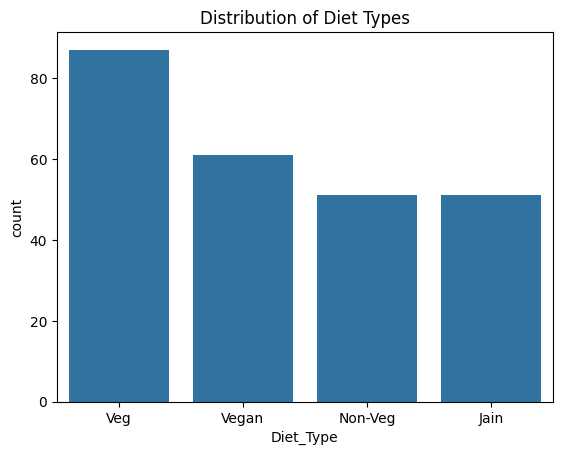

In [ ]:
print(df['Diet_Type'].value_counts())
sns.countplot(data=df, x='Diet_Type', order=df['Diet_Type'].value_counts().index)
plt.title('Distribution of Diet Types')
plt.show()

2. Most Common Physical Activity Level


Activity_Level
Light          66
Very Active    50
Sedentary      45
Moderate       45
Active         44
Name: count, dtype: int64


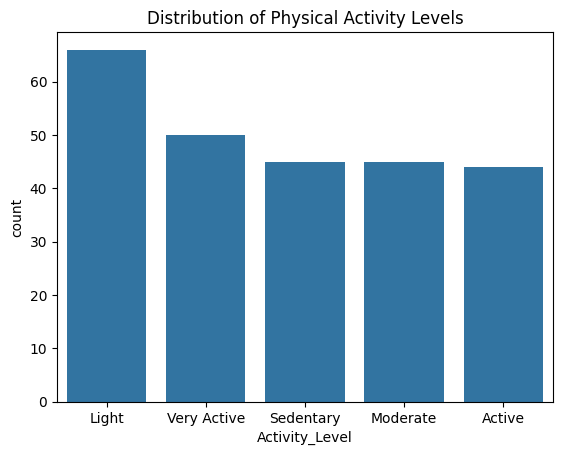

In [ ]:
print(df['Activity_Level'].value_counts())
sns.countplot(data=df, x='Activity_Level', order=df['Activity_Level'].value_counts().index)
plt.title('Distribution of Physical Activity Levels')
plt.show()

3.Predominant Age Group  



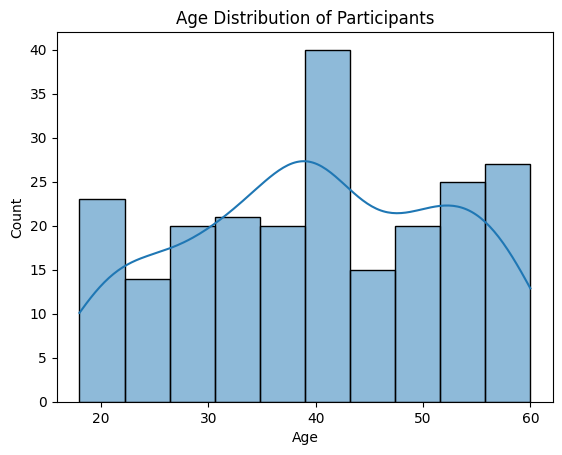

In [ ]:
sns.histplot(data=df, x='Age', bins=10, kde=True)
plt.title('Age Distribution of Participants')
plt.show()

4. Distribution and Ratio of Male and Female Participants.

Gender
Male      131
Female     94
Name: count, dtype: int64
Gender
Male      58.222222
Female    41.777778
Name: proportion, dtype: float64


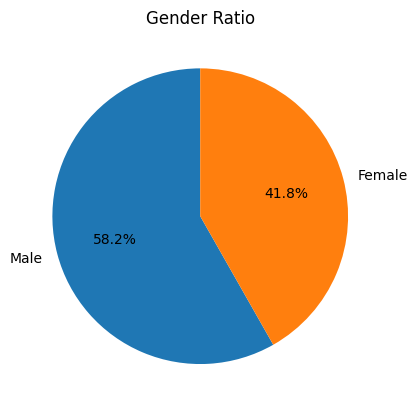

In [ ]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)
# Percentage breakdown
print(df['Gender'].value_counts(normalize=True) * 100)

plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Ratio')
plt.show()

## Bivariate Analysis
  

1. Which goal requires the highest calorie intake?

Goal
Gain        2615.526786
Maintain    2436.463768
Lose        2240.000000
Name: Daily_Calorie_Requirement, dtype: float64


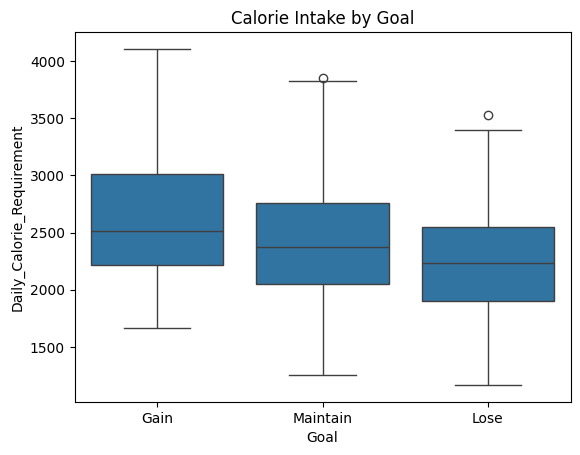

In [ ]:
print(df.groupby('Goal')['Daily_Calorie_Requirement'].mean().sort_values(ascending=False))
sns.boxplot(data=df, x='Goal', y='Daily_Calorie_Requirement')
plt.title('Calorie Intake by Goal')
plt.show()

2. Iscalorie requirement affected by age?

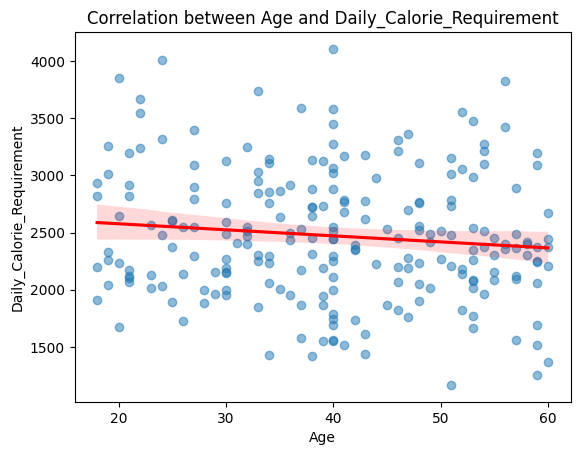

Correlation: -0.11318707589345482


In [ ]:
sns.regplot(data=df, x='Age', y='Daily_Calorie_Requirement', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation between Age and Daily_Calorie_Requirement')
plt.show()

# Calculate Pearson correlation coefficient
print("Correlation:", df['Age'].corr(df['Daily_Calorie_Requirement']))

3. Relation between Water Intake by Activity Level?

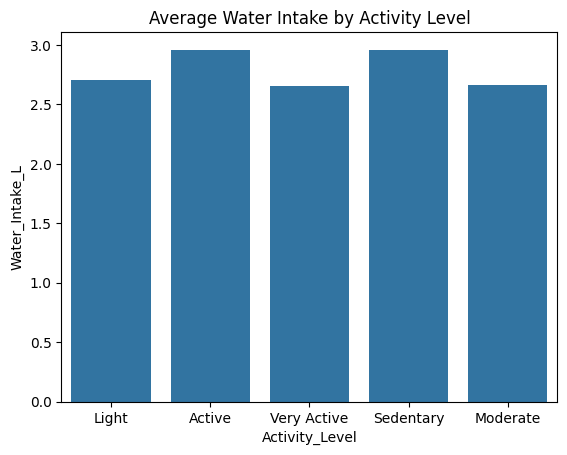

In [ ]:
sns.barplot(data=df, x='Activity_Level', y='Water_Intake_L', errorbar=None)
plt.title('Average Water Intake by Activity Level')
plt.show()

## Multivariate Analysis

  1. Calories by Activity Level and Gender   

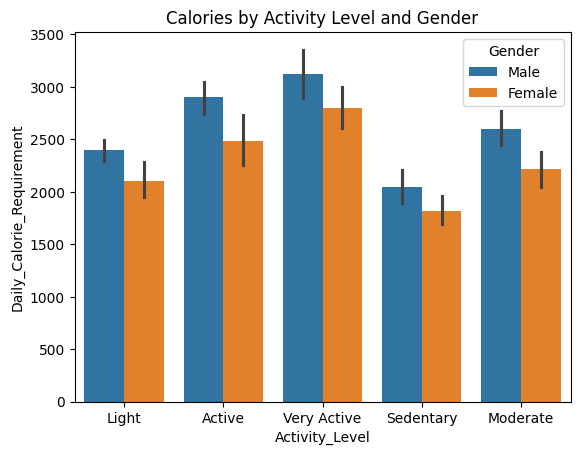

In [ ]:
sns.barplot(data=df, x='Activity_Level', y='Daily_Calorie_Requirement', hue='Gender')
plt.title('Calories by Activity Level and Gender')
plt.show()

2. Correlation Heatmap

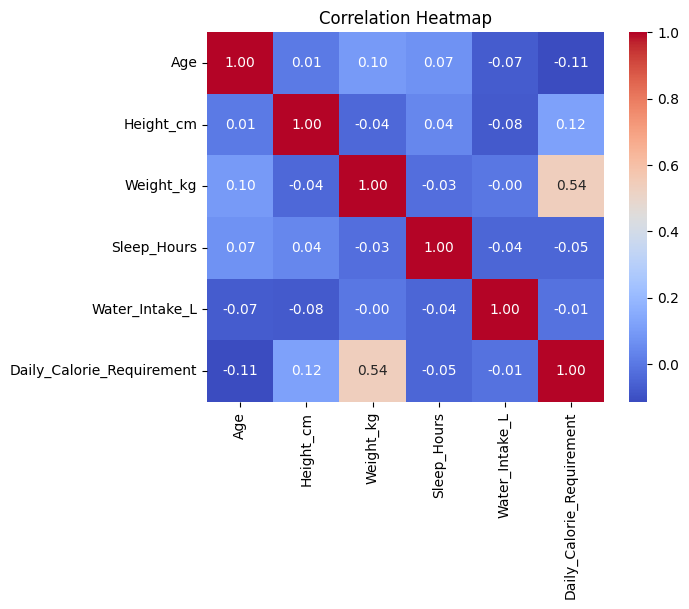

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

3. Treemap & Sunburst Chart

In [29]:
import plotly.express as px

# Treemap
fig_tree = px.treemap(df, path=['Goal', 'Activity_Level', 'Diet_Type'], title="Treemap: Goal -> Activity -> Diet")
fig_tree.show()



4. Sunburst Chart

In [30]:
# Sunburst Chart
fig_sun = px.sunburst(df, path=['Goal', 'Activity_Level', 'Diet_Type'], title="Sunburst: Goal -> Activity -> Diet")
fig_sun.show()

## Linear Regression Model

Mean Squared Error (Loss): 53292.85
Root Mean Squared Error: 230.85
R-squared Score: 0.86


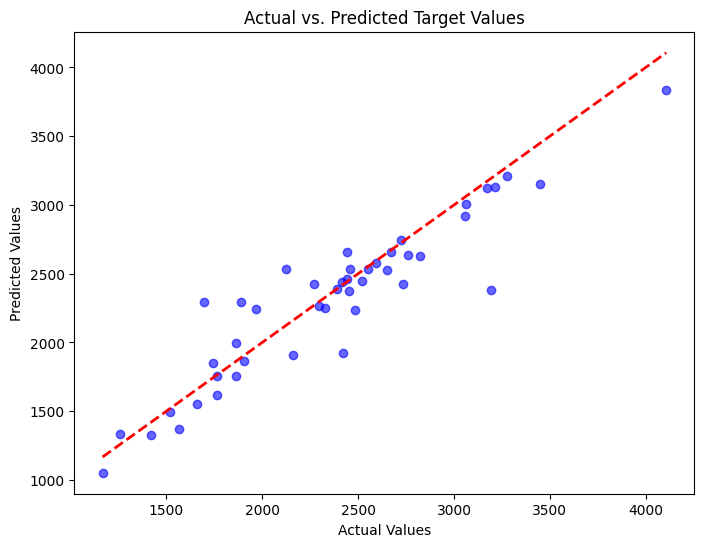

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separate Features (X) and Target (y)
# Let's assume your target variable is 'Calories' (or 'Charges')
target_col = 'Daily_Calorie_Requirement'

# Drop rows with NaN values from the DataFrame before splitting and encoding
df_cleaned = df.dropna()

X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

# 2. Handle Categorical Data via One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Compute Loss & Performance Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (Loss): {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

# 7. Visualize Targets vs Predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Target Values')
plt.show()